In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 현재 경로 확인
!pwd

/content


In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

/content/drive/My Drive/Colab Notebooks


#### 코랩에서 한국어 표시하기

In [ ]:
!apt-get install fonts-nanum* -qq
# 다운받은 후 코랩 런타임 다시 시작

In [3]:
# %matplotlib inline  # 별도의 plt.show()를 호출하지 않아도 그래프가 노트북 내부에 자동으로 출력됨
import matplotlib.pyplot as plt
import matplotlib as mpl 

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 패치
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = mpl.font_manager.FontProperties(fname=path).get_name()
plt.rcParams['font.family'] = font_name

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\usr\\share\\fonts\\truetype\\nanum\\NanumGothic.ttf'

# PyTorch 기본 활용법 및 심층신경망 심화 

## 수업 목차 

 
[1. PyTorch 기본 개념 & 텐서(Tensor) 구조](#one)<br>
- PyTorch의 특징과 기본 개념 
- 텐서(Tensor)란? (NumPy와 비교) 
- PyTorch에서 텐서 생성 및 연산 실습

[2. PyTorch 기본 활용법 실습](#two)<br>
- 속성확인 연산 4가지
- 인덱싱 및 슬라이싱 연산 
- 변환 연산 
- 행렬 연산
- GPU 사용하기 (CUDA 활용) 
- Autograd(자동 미분) 개념과 실습 
- no_grad, detach

[3. 모델 정의 3가지 방법](#three)<br>
- nn.Sequential()
- nn.Module 상속
- functional API (F)

[4. 딥러닝 학습 과정 심화](#four)<br>
- 손실 함수(Loss Function) 개념 (MSE, Cross-Entropy) 
- 옵티마이저(Optimizer) 개념 소개 (SGD, Adam, RMSprop)

[5. 과적합 방지 기법](#five)<br>
- Dropout(드롭아웃)
- Regularization(정규화)
- Eary stopping(조기종료)
- BatchNormalization(배치 정규화)

[6. Kaggle 데이터 셋을 활용한 DNN 학습 실습](#six)<br>

## <a id='one'>1. PyTorch 기본 개념 & 텐서(Tensor) 구조</a><br>

### [PyTorch 설치]
- https://pytorch.org/get-started/locally/

In [2]:
%pip install torch torchvision torchaudio 
# !pip install torch torchvision torchaudio 

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/204.2 MB ? eta -:--:--
   ---------------------------------------- 2.1/204.2 MB 10.7 MB/s eta 0:00:19
    --------------------------------------- 4.5/204.2 MB 11.2 MB/s eta 0:00:18
   - -------------------------------------- 7.1/204.2 MB 11.5 MB/s eta 0:00:18
   - -------------------------------------- 9.4/204.2 MB 11.5 MB/s eta 0:00:17
   -- ------------------------------------- 11.8/204.2 MB 11.5 MB/s eta 0:00:17
   -- ------------------------------------- 14.2/204.2 MB 11.5 MB/s eta 0:00:17
   --- ------------------------------------ 16.8/204.2 MB 11.5 MB/s eta 0:00:17
   --- ------------------------------------ 19.1/204.2 MB 11.5 MB/s eta 0:00:17
   ---- ----------------------------------- 21.8/204.2 MB 11.6 MB/s eta 0:00:16
   ---- ----------------------------------- 23.3/204.2 MB 11.4 MB/s eta 0:00:16
   ---- ----------------------------------- 25.4/204.2 MB 11.1 MB/s et

### [PyTorch 튜토리얼]
- https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

## PyTorch
> PyTorch는 Facebook의 AI 연구팀(FAIR)에서 개발한 오픈소스 머신러닝 라이브러리로, 특히 딥러닝(Deep Learning) 모델을 구축하고 학습하는 데 최적화된 프레임워크 <br>
> 쉽게 말해, 컴퓨터가 “학습”을 할 수 있게 도와주는 도구

### PyTorch의 주요 특성

## 🐝 쉬운 설명 

### 1️⃣ 동적 계산 그래프 
> 딥러닝 모델이 학습하는 동안 필요한 계산 과정을 실시간으로 만들어가는 방식.

#### 👍 장점
1. 학습 도중 모델의 구조를 수정하거나 새로운 계산을 추가할 수 있다. (실험하기 좋음)
2. 복잡한 모델의 구조를 직관적으로 구현할 수 있다. (가독성 향상, 비교적 쉬운 구현)
3. 연산에 문제가 생겼을 때 쉽게 찾아낼 수 있다. (디버깅이 용이함)

#### 👎 단점 
1. 정적 계산 그래프 보다 실행 속도가 느릴 수 있다. (낮은 성능)
2. 동일한 코드여도 실행환경이나 입력 데이터에 따라서 결과가 달라질 수 있다. (재현 불가능성)
3. 학습 하는 동안 구조가 추가되기 때문에 메모리 사용량이 증가할 수 있다. (어려운 메모리 관리)

### 2️⃣ 직관적인 Pythonic 문법 
> 파이썬 코드 스타일과 유사해서 비교적 학습하기 쉬움

### 3️⃣ 강력한 GPU 가속 지원 
> Numpy 데이터 타입은 GPU를 사용할 수 없어 많은 데이터를 빠르게 연산 할 수 없지만, <br>
> PyTorch의 Tensor 데이터 타입은 GPU 연산을 통해 빠른 연산이 가능하다

### 4️⃣ 자동 미분 
> 딥러닝 모델을 학습할 때 필요한 기울기(gradient)를 자동으로 계산해주는 기능 <br> 
> 딥러닝 모델이 잘 예측할 수 있도록 학습하는 과정에서 꼭 필요한 연산을 자동으로 해주는 기능 

#### 👍 장점
1. 간단한 함수 실행으로 미분을 구할 수 있다 (효율적인 연산)
2. 사람이 직접 계산값을 입력하지 않아도 되기 때문에 실수를 방지할 수 있다 (정확성)
3. GPU를 활용하여 빠른 연산이 가능하다 (빠른 속도)

#### 👎 단점 
1. 연산 기록을 저장해야 하기 때문에 메모리 사용량이 증가합니다. (메모리 사용량 증가)
2. 복잡하지 않은 모델에서 GPU를 사용하여 자동미분을 하면 오히려 속도가 느릴 수 있다. (높은 오버헤드)

🛠️ 오버헤드: 어떤 작업을 수행하는 데 있어서 직접적인 연산이나 실행 외에 추가적으로 발생하는 비용(시간, 메모리, 리소스 등)을 의미. 쉽게 말해, "일을 직접 하는 시간보다, 준비하는 시간이 더 오래 걸리는 상황" <br>
예를 들어, 딸기를 갈아서 주스를 만든다고 가정했을 때, 딸기 하나를 갈아서 주스를 만든다고 하면 바로 칼로 다져서 만들면 빠르지만 (CPU), 딸기를 10개 이상 다져서 주스로 만들어야 한다고 하면 처음에 믹서기를 가져와서 콘센트를 꼽고, 믹서기 안을 세척하고 하는 작업만 거친다면 10개를 한 번에 갈아낼 수 있기 때문에 훨씬 더 빠를 수 있다. <br>
여기서 **오버헤드에 해당하는 것은 믹서기를 가져오는 것, 믹서기를 세척하는 것** 


```
🔹 동적 계산 그래프(Dynamic Computational Graph)
PyTorch는 실행 시점에서 연산 그래프를 동적으로 생성해.
TensorFlow의 경우 그래프를 먼저 정의한 후 실행하는 정적 계산 그래프(Static Computational Graph) 방식을 사용하지만, 
PyTorch는 코드 실행과 동시에 그래프가 생성돼서 더 직관적이고 디버깅이 쉬워.
예를 들어, 모델 구조를 실험하면서 즉시 변경할 수 있어 연구에 매우 유리해.

🔹 직관적인 Pythonic 문법
PyTorch는 Python 스타일의 문법을 따르기 때문에 NumPy처럼 쉽게 사용할 수 있어.
실제로 PyTorch의 텐서는 NumPy 배열과 매우 유사하며, GPU 연산을 지원하는 확장된 형태라고 볼 수 있어.

🔹 강력한 GPU 가속 지원
PyTorch의 torch.Tensor 객체는 GPU에서 연산할 수 있는 기능을 내장하고 있어.
.cuda()를 사용하면 GPU에서 빠르게 연산할 수 있어 학습 속도를 높일 수 있어.

🔹 자동 미분(Autograd)
PyTorch에서는 자동으로 미분을 계산하는 Autograd 기능을 제공해.
신경망을 학습할 때 손실 함수(Loss Function)에 대한 기울기(Gradient)를 자동으로 계산해줘서 역전파(Backpropagation)를 쉽게 구현할 수 있어.

🔹 유연한 모델 구성
PyTorch는 딥러닝 모델을 쉽게 만들고 수정할 수 있도록 다양한 API를 제공해.
특히 torch.nn.Module을 사용하면 신경망 모델을 쉽게 정의할 수 있어.

🔹 배포 및 생산 환경 지원
최근에는 PyTorch의 TorchScript 기능을 활용해 모델을 변환하고, 프로덕션 환경에서도 사용할 수 있도록 지원하고 있어.
Facebook, Tesla, OpenAI 등의 기업에서도 PyTorch를 활용해 모델을 학습하고 배포하고 있어.
```

### 자동 미분 (오차 역전파 과정에서 하는 연산) (🐝 쉬운 설명)

```
🍔 햄버거 공장에서 일한다고 생각해보자!

네가 햄버거 가게에서 일하고 있는데, 하나의 햄버거를 만들기 위해 여러 단계의 과정이 필요해.

1️⃣ 빵을 준비한다
2️⃣ 패티를 굽는다
3️⃣ 치즈를 올린다
4️⃣ 야채를 추가한다
5️⃣ 소스를 바른다
6️⃣ 햄버거를 포장한다

지금 너는 가게의 매니저고, 각 단계가 햄버거의 맛에 얼마나 영향을 주는지(기울기, 즉 미분 값) 알아야 해.
예를 들어, 패티를 태우면 맛이 확 떨어지고, 소스가 조금 덜 들어가도 큰 차이가 없다면?
이런 정보를 바탕으로 “어디를 개선해야 할까?” 를 판단할 수 있어야 하지.

🛠️ 여기서 1번부터 6번까지는 각각 서로 다른 레이어라고 생각하시면 됩니다.

🤯 직접 손으로 다 계산해야 한다면?

이제 너는 매장 운영을 최적화하기 위해, 햄버거의 “맛 점수”가 각 단계에서 얼마나 변하는지 분석하려고 해.

하지만 문제는, 너 혼자 100가지 다른 햄버거 레시피를 분석해야 한다는 것!
각 단계별로 햄버거의 맛 점수를 조금씩 바꿔보고(미분) 그 변화율을 계산해야 해.
1. 패티의 굽는 시간을 10초 줄였을 때 맛이 얼마나 변하는지?
2. 소스를 5g 더 추가하면?
3. 치즈를 한 장 더 올리면?

이걸 수작업으로 하면 너무 느리고 비효율적이지. 🤯
이게 바로 사람이 직접 손으로 미분을 계산하는 것과 같은 상황이야.

✅ 여기서는 햄버거의 맛 점수를 높이는 방향으로 각 단계에서 어떻게 수정해야할지 결정한다면, 
   딥러닝 모델 학습 시에는 예측값과 정답값의 오차를 낮추는 방향으로 수정하려 한다는 것! 
   100가지 다른 햄버거 -> 입력(학습) 데이터
```

### 계산 그래프

> 수학적 연산을 그래프 자료구조로 표현한 것으로, 데이터와 연산을 각각 노드와 간선으로 나타낸다 <br>
> 신경망 학습 과정 즉, 순전파, 역전파를 그래프로 나타내어 직관적으로 표현하고 이를 효율적으로 연산할 수 있다. 

- 노드(Node): 변수(입력값, 가중치, 중간 연산 결과) 또는 연산
- 간선(Edge): 연산의 흐름을 나타내는 연결선 (데이터가 전달되는 경로)

In [10]:
# 계산 그래프를 딕셔너리 자료구조로 표현
computational_graph = {
    "a": {"value": 2, "parents": []},
    "b": {"value": 3, "parents": []},
    "+": {"value": None, "parents": ["a", "b"]},
    "c": {"value": 4, "parents": []},
    "*": {"value": None, "parents": ["+", "c"]},
    "Output": {"value": None, "parents": ["*"]}
}

# 순전파 계산
computational_graph["+"]["value"] = computational_graph["a"]["value"] + computational_graph["b"]["value"]  # (2 + 3)
computational_graph["*"]["value"] = computational_graph["+"]["value"] * computational_graph["c"]["value"]  # (5 * 4)
computational_graph["Output"]["value"] = computational_graph["*"]["value"]  

# 결과 출력
for node, data in computational_graph.items():
    print(f"{node}: {data['value']}")

a: 2
b: 3
+: 5
c: 4
*: 20
Output: 20


In [4]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_graph(graph):
    G = nx.DiGraph()  # 방향성이 있는 그래프
    
    # 노드 추가
    for node, data in graph.items():
        label = f"{node}\n({data['value']})"
        G.add_node(node, label=label)

    # 엣지 추가 (연산 흐름을 나타냄)
    for node, data in graph.items():
        for parent in data["parents"]:
            G.add_edge(parent, node)

    # 노드 위치 설정
    pos = {
        "a": (-1, 2), "b": (1, 2), "+": (0, 1.5),
        "c": (2, 1.5), "*": (0.5, 0.5), "Output": (0.5, 0)
    }

    # 노드 라벨 가져오기
    labels = nx.get_node_attributes(G, "label")

    # 그래프 시각화
    plt.figure(figsize=(6, 5))
    nx.draw(G, pos, with_labels=True, labels=labels, node_size=3000, node_color="lightblue", edge_color="gray", font_size=10, font_weight="bold")
    plt.title("Computational Graph Visualization")
    plt.show()

# 그래프 그리기
draw_graph(computational_graph)

NameError: name 'computational_graph' is not defined

### 계산 그래프의 장점 

- 연산과정이 명확해지고 디버깅이 쉬워짐 
- 자동 미분이 가능해짐 -> 변수 간의 관계가 연결되어 있어 체인룰 기반으로 미분을 하기 쉬워짐 
- 연산을 모듈화 할 수 있어 새로운 연산을 추가하거나 수정하기 수월함 

In [5]:
import torch

# 자동 미분을 위한 변수 설정
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = torch.tensor(4.0, requires_grad=True)

# 순전파 연산 (계산 그래프 생성됨) 
L = (x + y) * z

# 역전파 실행 (자동으로 그래프를 따라가면서 미분 계산)
L.backward()

# 미분값 확인
print("dL/dx:", x.grad)  # 4.0
print("dL/dy:", y.grad)  # 4.0
print("dL/dz:", z.grad)  # 5.0

dL/dx: tensor(4.)
dL/dy: tensor(4.)
dL/dz: tensor(5.)


In [18]:
L.grad_fn, # 마지막 연산을 나타냄 

((<AddBackward0 at 0x108f2ff40>, 0), (<AccumulateGrad at 0x108f2ed70>, 0))

In [1]:
import tensorflow as tf
import numpy as np

In [2]:
tf.__version__, np.__version__ # ('2.19.0', '2.1.3') / ('2.19.0', '1.26.0')

('2.19.0', '1.26.0')

In [2]:
@tf.function  # 정적 계산 그래프 모드 적용
def compute_gradients(x, y, z):
    with tf.GradientTape() as tape:
        L = (x + y) * z  # 순전파 수행
    return tape.gradient(L, [x, y, z])  # 미분값 반환

# 변수 정의
x = tf.Variable(2.0)
y = tf.Variable(3.0)
z = tf.Variable(4.0)

# 함수 실행 (정적 그래프 모드에서 실행됨)
gradients = compute_gradients(x, y, z)
print("dL/dx:", gradients[0])  # 4.0
print("dL/dy:", gradients[1])  # 4.0
print("dL/dz:", gradients[2])  # 5.0


dL/dx: tf.Tensor(4.0, shape=(), dtype=float32)
dL/dy: tf.Tensor(4.0, shape=(), dtype=float32)
dL/dz: tf.Tensor(5.0, shape=(), dtype=float32)


|	|PyTorch (Dynamic Graph)|	TensorFlow (Static Graph)
---|---|---
그래프 생성 시점|	연산 수행 시 즉시 생성|	@tf.function을 사용하면 미리 생성됨
유연성|	실행할 때마다 그래프가 변경 가능|	미리 생성된 그래프를 수정할 수 없음
디버깅|	일반적인 Python 코드처럼 실행 가능|	그래프 실행 전에는 중간 값을 쉽게 볼 수 없음
최적화 가능 여부|	그래프가 매번 새로 생성되므로 최적화 어려움|	미리 생성된 그래프를 최적화할 수 있음
적용 사례|	실험 및 연구에 유리|	대규모 학습, 배포 환경에서 최적화 가능

> 요즘은 PyTorch도 torch.jit을 활용해서 정적 그래프처럼 최적화가 가능하고, <br>
> Tensorflow에서도 동적 그래프가 가능함

#### 💡 왜 그래프를 미리 만들어 두기도 하고 동적으로 실행할때 마다 그래프가 바뀌기도 해야 하는 걸까?

#### ➡️ 입력 데이터 길이가 가변적인 경우 동적 계산 그래프를 통해 연산을 해야 함 

## 텐서
> 다차원 배열 구조를 가진 데이터 구조 <br>
> Numpy 배열과 유사하지만 GPU 연산이 가능하다는 차이점이 있다

✅ 이론적으로 3차원 배열이상 부터 텐서라고 부르지만, <br>
torch.Tensor 객체는 1차원 배열(벡터)부터 “Tensor”라고 부른다.

<img src="사진/tensor.png" alt="tensor"/>

출처: https://hiddenbeginner.github.io/deeplearning/2020/01/21/pytorch_tensor.html

특징|	NumPy|	PyTorch Tensor
---|---|---
데이터 타입|	ndarray|	torch.Tensor
연산 지원|	기본 연산 지원|	GPU 연산 및 Autograd 지원
미분 계산|	지원 안 함|	자동 미분 가능 (requires_grad=True)
계산 그래프|	없음|	동적 계산 그래프 지원

In [2]:
import numpy as np
import torch

In [3]:
x1 = np.array([[1, 2], [3, 4]])
x2 = torch.tensor([[1, 2], [3, 4]])

In [4]:
x1

array([[1, 2],
       [3, 4]])

In [5]:
x2

tensor([[1, 2],
        [3, 4]])

In [4]:
x = torch.zeros(1)

In [5]:
type(x)

torch.Tensor

## 텐서를 만드는 방법

```
✅ 기존 데이터를 변환하는 방법
✅ 랜덤 데이터로 텐서를 생성하는 방법
✅ 특정 값으로 초기화하는 방법
✅ 다른 텐서의 속성을 따라 텐서를 생성하는 방법
✅ 그 밖의 방법
```

### 1. 기존 데이터를 변환 하는 방법

In [19]:
# 리스트를 텐서로 변환
t1 = torch.tensor([1, 2, 3])
t2 = torch.tensor([[1.5, 2.5], [3.5, 4.5]])

# NumPy 배열을 텐서로 변환
np_array = np.array([5, 6, 7])
t3 = torch.tensor(np_array) # 데이터가 복사되어 저장됨 

In [8]:
type(t1)

torch.Tensor

In [9]:
t1.dtype

torch.int64

In [20]:
np_array[0] = 1

In [21]:
t3

tensor([5, 6, 7])

In [13]:
np_array = np.array([8, 9, 10])
t4 = torch.from_numpy(np_array) # numpy 배열을 텐서로 변환 (메모리 공유)

In [14]:
id(np_array), id(t4)

(4912348112, 4912344592)

In [16]:
np_array[0] = 1

In [17]:
t4

tensor([ 1,  9, 10])

### 2. 랜덤 데이터로 텐서를 생성하는 방법 

In [22]:
t5 = torch.rand(2, 3) # 0 ~ 1 사이 랜덤 값 / 인자: 텐서의 크기 

In [23]:
t5.shape

torch.Size([2, 3])

In [ ]:
t6 = torch.randn(2, 3) # 평균 0, 표준편차 1인 정규 분포에서 랜덤 

In [27]:
t6

tensor([[ 0.3753, -0.5918,  0.7242],
        [ 0.0903, -1.1064,  3.3197]])

In [29]:
t7 = torch.randint(0, 10, (2, 3))  # 0~9 사이 정수 랜덤 생성

In [30]:
t7

tensor([[8, 5, 6],
        [1, 8, 8]])

### 3. 특정 값으로 초기화 하는 방법

In [ ]:
t8 = torch.zeros(2, 3) # 모든 값이 0

In [ ]:
t9 = torch.ones(2, 3) # 모든 값이 1

In [33]:
t10 = torch.full((2, 3), 7) # 특정 값으로 채워진 텐서 

In [36]:
t11 = torch.arange(0, 10, 2)  # 특정 범위 값으로 1D 텐서 생성 (0부터 10미만까지 2씩 증가)

In [35]:
t11

tensor([0, 2, 4, 6, 8])

In [37]:
t12 = torch.linspace(0, 10, 5)  # 균등한 간격의 값으로 1D 텐서 생성 0에서 10까지 5개의 값 생성

In [ ]:
t13 = torch.eye(3)  # 3x3 단위 행렬 -> One-hot encoding에서 자주 활용됨 

### 4. 다른 텐서의 속성을 따라 텐서를 생성하는 방법

In [134]:
base = torch.tensor([[1, 2, 3], [4, 5, 6]])

t14 = torch.zeros_like(base)  # 같은 크기의 0 텐서 생성
t15 = torch.ones_like(base)   # 같은 크기의 1 텐서 생성

In [135]:
base2 = torch.tensor([[1., 2., 3.], [4., 5., 6.]])

t16 = torch.rand_like(base2)   # 같은 크기의 랜덤 텐서 생성
t17 = torch.randn_like(base2)  # 같은 크기의 정규분포 랜덤 텐서 생성

t18 = torch.rand_like(base, dtype=torch.float)

In [136]:
t18

tensor([[0.8102, 0.1378, 0.8452],
        [0.2029, 0.3440, 0.4816]])

### 그 밖의 방법들

In [138]:
t19 = torch.empty(2, 3) # 초기화되지 않은 텐서
t20 = torch.empty_like(base) #  특정 텐서와 같은 크기, 초기화되지 않은 텐서

In [139]:
t19

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [140]:
t8 == t19 # torch.zeros랑 겉 보기엔 같을떄가 있다 

tensor([[True, True, True],
        [True, True, True]])

### Quiz1.

1. 크기가 3x3이고 모든 값이 정수 7인 텐서 
2. 랜덤 값으로 채워진 4x2 텐서
3. 크기가 5x5인 단위 행렬
4. 평균이 0, 표준편차가 1인 랜덤한 값으로 채워진 6x2 텐서
5. 값이 2부터 10으로 채워진 텐서

## <a id='two'>2. PyTorch 기본 활용법 실습</a><br>

### 속성 확인 연산 4가지
> 텐서의 크기, 차원, 데이터 타입 등을 확인할 수 있다 

```
1. shape 또는 size: 텐서의 크기 반환
2. dtype: 데이터 타입 반환 (예: torch.float32)
3. device: 텐서가 할당된 디바이스 (CPU/GPU) 확인
4. dim(): 텐서의 차원 수 반환
```

In [104]:
a = torch.tensor([[1,2,3], [1,2,3]])

In [105]:
a.shape, a.size()

(torch.Size([2, 3]), torch.Size([2, 3]))

In [106]:
a.dtype

torch.int64

In [107]:
a.device

device(type='cpu')

In [270]:
a.dim()

1

### 인덱싱 및 슬라이싱 연산 (Indexing & Slicing)
> 텐서의 특정 요소를 참조하거나 부분 텐서를 추출할 수 있다. 

```
1. tensor[i]: i번째 요소 접근
2. tensor[i, j]: i행 j열 요소 접근 (2D 텐서 이상)
3. tensor[:, i]: 모든 행에서 i열의 요소 추출
4. tensor[i:j]: i부터 j-1까지 슬라이싱
5. tensor[mask]: Boolean 마스크를 이용한 필터링 -> 결과는 항상 1D 텐서
```

In [109]:
a

tensor([[1, 2, 3],
        [1, 2, 3]])

In [110]:
a[0]

tensor([1, 2, 3])

In [111]:
a[0, 0]

tensor(1)

In [112]:
a[:, 2]

tensor([3, 3])

In [113]:
a[2:4]

tensor([], size=(0, 3), dtype=torch.int64)

In [114]:
a[a > 1]

tensor([2, 3, 2, 3])

In [ ]:
a[[True, False]] # 첫째 행만 인덱싱

tensor([[1, 2, 3]])

In [121]:
mask = torch.zeros_like(a, dtype=bool)

In [122]:
mask

tensor([[False, False, False],
        [False, False, False]])

In [123]:
mask[:, 0] = True # 모든 행에서 첫번째 행의 값을 True로 할당

In [124]:
mask

tensor([[ True, False, False],
        [ True, False, False]])

In [125]:
a[mask]

tensor([1, 1])

### Quiz2.

> 1. 5보다 큰 값들만 인덱싱하시오 <br> 
> 2. 빨간색으로 표시된 부분을 인덱싱하시오

In [162]:
a = torch.tensor([
    [[1, 2], [4, 3], [7, 4]],  
    [[2, 0], [9, 0], [7, 5]],  
    [[1, 0], [3, 0], [0, 2]],  
    [[9, 0], [6, 0], [9, 8]]  
])

In [137]:
a.shape

torch.Size([4, 3, 2])

<img src="사진/3d_tensor1.png"  width=300 height=300 alt="3d_tensor1"/>

<img src="사진/3d_tensor2.png"  width=300 height=300 alt="3d_tensor2"/>

### 변환 연산
> 형태를 변경하거나 데이터 타입을 변환할 수 있습니다.

```
1. view(shape): 크기 변경 (기존 데이터 유지) 
-> 원본 데이터의 메모리를 공유하고 형태만 변경 + 연속적인 메모리를 갖는 데이터만 변경 가능
2. reshape(shape): 크기 변경 (자동으로 맞춤) 
-> 원본 데이터의 메모리가 연속적이건 연속적이지 않건 크기를 변경할 수 있음
3. permute(dims): 차원의 순서를 변경
4. transpose(dim0, dim1): 특정 두 차원의 위치를 교환
5. squeeze(dim): 크기가 1인 차원을 제거
```

In [227]:
a = torch.arange(12)
b = torch.tensor([[1,2,1],[5,5,1]])

In [228]:
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [229]:
b = a.view(2, 6)

In [230]:
c = b.transpose(1,0)

In [234]:
c.shape

torch.Size([6, 2])

In [ ]:
c.view(2,6) # transpose 연산을 하면서 메모리가 비연속적으로 변하여 view 연산이 안됨

RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [236]:
c.reshape(2, 6)

tensor([[ 0,  6,  1,  7,  2,  8],
        [ 3,  9,  4, 10,  5, 11]])

In [237]:
d = torch.arange(24)
d = d.view(2,3,4)

In [240]:
e = d.permute(0, 2, 1)

In [241]:
e.shape

torch.Size([2, 4, 3])

In [244]:
f = torch.arange(24)
f = f.reshape(12, 2, 1)

In [245]:
f.shape

torch.Size([12, 2, 1])

In [247]:
g = f.squeeze()

In [248]:
g.shape

torch.Size([12, 2])

### 행렬 연산 (Matrix Operations)

```
1. torch.matmul(A, B): 행렬 곱셈
-> 브로드 캐스팅을 지원하는 행렬 곱 연산, 1D, 2D, 3D 이상의 텐서에도 적용 가능
2. torch.mm(A, B): 2D 행렬 곱셈
-> 2D 행렬 곱에서만 동작, 브로드 캐스팅 X
3. torch.bmm(A, B): 배치(batch) 행렬 곱셈
-> 브로드 캐스팅 X 
4. torch.t(A): 전치 행렬 (대각선을 기준으로 행(row)과 열(column)을 뒤집는 연산)
-> 2차원 이하의 행렬에서 사용
```

#### 행렬 곱 연산

<img src="사진/dot.png" alt="dot"  width="700px" height="500px"/>

In [249]:
# 2D 행렬 곱 (기본적인 행렬 연산)
A = torch.randn(2, 3)
B = torch.randn(3, 4)

result = torch.matmul(A, B)  # (2,3) @ (3,4) → (2,4)
print("matmul result:\n", result)

matmul result:
 tensor([[ 1.8701, -0.9330,  0.5987,  1.9611],
        [-4.0317,  3.0043, -1.9164, -1.3755]])


#### 브로드 캐스팅 (broadcasting)

> 두 배열 간의 연산 과정을 수행할 때 배열 간 Shape가 다를 경우 두 배열 간의 형상을 맞추는 작업

<img src="사진/broadcasting.png" alt="broadcasting" width="700px" height="500px"/>

In [9]:
a = torch.ones(3, 4)
b = torch.arange(0, 4)

a * b

tensor([[0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.]])

<img src="사진/broadcasting2.png" alt="broadcasting2"  width="700px" height="500px"/>

In [250]:
A = torch.randn(2, 3, 4)  # (batch=2, 3x4 행렬)
B = torch.randn(2, 4, 5)  # (batch=2, 4x5 행렬)

In [252]:
torch.bmm(A,B)

tensor([[[ 0.8979,  0.1495, -3.2750, -1.1612,  1.9346],
         [ 0.5822,  2.2598,  2.5366,  0.3447, -1.5940],
         [-1.5133,  1.8261,  0.5287,  2.7533,  2.0659]],

        [[ 0.3738,  0.0678,  0.7598,  1.4273,  0.6128],
         [-0.1917,  1.0715, -0.8586,  1.2076,  1.7258],
         [ 0.0810,  0.2208, -1.4098, -2.9762, -1.8306]]])

In [253]:
torch.matmul(A, B)

tensor([[[ 0.8979,  0.1495, -3.2750, -1.1612,  1.9346],
         [ 0.5822,  2.2598,  2.5366,  0.3447, -1.5940],
         [-1.5133,  1.8261,  0.5287,  2.7533,  2.0659]],

        [[ 0.3738,  0.0678,  0.7598,  1.4273,  0.6128],
         [-0.1917,  1.0715, -0.8586,  1.2076,  1.7258],
         [ 0.0810,  0.2208, -1.4098, -2.9762, -1.8306]]])

In [254]:
A

tensor([[[ 2.2406, -0.6877, -1.1514,  0.3558],
         [-1.1531, -0.4652,  0.5453,  0.4997],
         [ 0.2825,  0.5870,  1.7334,  0.5627]],

        [[-0.5861,  0.2255,  0.1985, -0.5573],
         [-0.8120, -0.3131, -0.7652,  0.1184],
         [ 0.9043,  1.4142, -0.1442, -0.3569]]])

In [23]:
test = torch.tensor([[1,2],[3,4]])
test2 = torch.tensor([1,2])

In [24]:
test

tensor([[1, 2],
        [3, 4]])

In [25]:
test.T

tensor([[1, 3],
        [2, 4]])

In [ ]:
torch.t(test)   # 이 방법을 권장

tensor([[1, 3],
        [2, 4]])

In [266]:
test2.T

tensor([1, 2])

In [267]:
torch.t(test2)

tensor([1, 2])

### GPU 사용하기

> Tensor 타입의 자료 구조는 연산을 수행할 디바이스 정보를 가지고 있고, <br>
> 연산을 수행하기 전에 디바이스 정보에 따라서 어떤 연산 처리 장치를 사용할지 지정할 수 있다

In [143]:
import torch 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용할 장치:", device)

사용할 장치: cpu


In [144]:
x = torch.tensor([1.0, 2.0, 3.0]).to(device)

In [145]:
x.device

device(type='cpu')

### 자동 미분 

> 계산 그래프 연산을 활용해서 미분값을 자동으로 구하는 방법 <br> 

In [ ]:
import torch

# 미분할 변수 x 정의 (requires_grad=True 설정!)
x = torch.tensor(3.0, requires_grad=True)

# 함수 y = x^2 정의
y = x**2  

# 자동 미분 실행
y.backward()  

# 결과 출력: dy/dx 값 확인
print(x.grad)  # 출력: tensor(6.)

tensor(6.)


In [36]:
xx = torch.tensor([1.], requires_grad=True)

In [37]:
xx.shape

torch.Size([1])

In [40]:
x = torch.tensor([[2.0, 3.0]], requires_grad=True)  # 입력값 (1 x 2 벡터)

# 첫 번째 레이어 (2 입력 → 3 뉴런)
W1 = torch.tensor([[1., 1., 1.], [1., 1., 1.]], requires_grad=True) # 가중치 행렬 (2x3
torch.matmul(x, W1)

tensor([[5., 5., 5.]], grad_fn=<MmBackward0>)

In [ ]:
import torch
import torch.nn as nn

# 입력값 정의 (x1, x2 두 개의 입력값 사용)
x = torch.tensor([[2.0, 3.0]], requires_grad=True)  # 입력값 (1 x 2 벡터)

# 첫 번째 레이어 (2 입력 → 3 뉴런)
W1 = torch.tensor([[1., 1., 1.], [1., 1., 1.]], requires_grad=True) # 가중치 행렬 (2x3)
b1 = torch.tensor([[1., 1., 1.]], requires_grad=True)  # 편향 (1x3)
h = torch.matmul(x, W1) + b1  # 선형 변환
h_relu = torch.relu(h)  # ReLU 활성화 함수 적용

# 두 번째 레이어 (3 입력 → 1 출력)
W2 =  torch.tensor([[1.], [1.], [1.]], requires_grad=True)  # 가중치 행렬 (3x1)
b2 = torch.tensor([1.], requires_grad=True)  # 편향 (1x1)
y = torch.matmul(h_relu, W2) + b2  # 최종 출력

# 역전파 실행 (자동 미분)
y.backward()

# 결과 출력 (각 파라미터의 기울기)
print("입력 x의 기울기 (∂y/∂x):")
print(x.grad)
print('--------------------------------------')
print("첫 번째 레이어 가중치 W1의 기울기 (∂y/∂W1):")
W1.grad
print("첫 번째 레이어 편향 b1의 기울기 (∂y/∂b1):")
b1.grad
print('--------------------------------------')
print("두 번째 레이어 가중치 W2의 기울기 (∂y/∂W2):")
print(W2.grad)
print("두 번째 레이어 편향 b2의 기울기 (∂y/∂b2):")
b2.grad

입력 x의 기울기 (∂y/∂x):
tensor([[3., 3.]])
--------------------------------------
첫 번째 레이어 가중치 W1의 기울기 (∂y/∂W1):
첫 번째 레이어 편향 b1의 기울기 (∂y/∂b1):
--------------------------------------
두 번째 레이어 가중치 W2의 기울기 (∂y/∂W2):
tensor([[6.],
        [6.],
        [6.]])
두 번째 레이어 편향 b2의 기울기 (∂y/∂b2):


tensor([1.])

$$
x = 
\begin{bmatrix}
2 & 3 
\end{bmatrix}
$$

$$
W_1 = 
\begin{bmatrix}
1 & 1 & 1 \\ 
1 & 1 & 1
\end{bmatrix}
$$

$$
b_1 = 
\begin{bmatrix}
1 & 1 & 1
\end{bmatrix}
$$

$$
h = x \cdot W_1 + b_1
$$

$$
h = 
\begin{bmatrix}
2 & 3 
\end{bmatrix}
\cdot
\begin{bmatrix}
1 & 1 & 1 \\ 
1 & 1 & 1
\end{bmatrix}
+ 
\begin{bmatrix}
1 & 1 & 1
\end{bmatrix}
= 
\begin{bmatrix}
6 & 6 & 6
\end{bmatrix}
$$



$$
hrelu = 
\begin{bmatrix}
6 & 6 & 6
\end{bmatrix}
$$

$$
W_2 = 
\begin{bmatrix}
1 \\
1 \\
1 
\end{bmatrix}
$$

$$
b_1 = 
\begin{bmatrix}
1 
\end{bmatrix}
$$

$$
y = hrelu \cdot W_2 + b_2
$$

$$
y = 
\begin{bmatrix}
6 & 6 & 6
\end{bmatrix}
\cdot
\begin{bmatrix}
1 \\
1 \\
1 
\end{bmatrix}
+ 
\begin{bmatrix}
1 
\end{bmatrix}
= 
\begin{bmatrix}
19
\end{bmatrix}
$$



## no_grad, detach

> no_grad, detach 모두 미분 계산이 필요하지 않는 연산을 할때 사용. 보통 평가 시에 사용하지 않음 (학습 중에도 사용하지 않는 경우도 있음 ex) BatchNorm <br> 
> no_grad: 블록 내 모든 연산 시 미분 값을 계산하지 않음 <br>
> detach: 특정 텐서만 미분 계산을 하지 않음 

In [175]:
import torch

# 미분이 필요한 텐서
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

# Autograd 적용
y.backward()
print("x.grad (미분값):", x.grad)  # 출력: 6.0

# no_grad() 사용 (그래프 저장 X)
with torch.no_grad():
    y_no_grad = x ** 2
print("y_no_grad requires_grad:", y_no_grad.requires_grad)  # False
print("y_no_grad grad:", y_no_grad.grad)

# detach() 사용
y_detach = y.detach()
print("y_detach requires_grad:", y_detach.requires_grad)  # False
print("y_detach grad:", y_detach.grad)

x.grad (미분값): tensor(6.)
y_no_grad requires_grad: False
y_no_grad grad: None
y_detach requires_grad: False
y_detach grad: None


### zero_grad
> 기울기 초기화 

### ※ 왜 기본적으로 미분 값을 자동으로 초기화 하지 않고 누적시키는 걸까? 
-> 배치 크기(Batch Size)가 너무 작아서 한 번의 역전파로 충분한 업데이트를 할 수 없을 때 <br>
여러 번의 미니배치를 처리하면서 기울기를 누적한 후 한 번에 업데이트하면 효과적이기 때문에 <br>
-> RNN 같은 순차 모델에서 긴 시퀀스를 처리할 때 기울기를 누적해야 함 (특이한 모델 구조로 인해 기울기를 누적해야 하는 경우가 있음) <br>
-> GAN(생성 모델) 학습 시 Generator와 Discriminator의 Loss를 조합하여 업데이트 (특이한 모델 구조로 인해 기울기를 누적해야 하는 경우가 있음)

In [178]:
w = torch.tensor(2.0, requires_grad=True)

# 손실 함수 예제
loss = w ** 2
loss.backward()

print("이전 기울기:", w.grad)  # 4.0

이전 기울기: tensor(4.)


In [181]:
# 기울기 초기화
w.grad.zero_()
print("초기화된 기울기:", w.grad)  # 0.0

초기화된 기울기: tensor(0.)


In [182]:
import torch

# 간단한 모델 정의
model = torch.nn.Linear(2, 1)  # 입력 2개, 출력 1개

# 옵티마이저 설정
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# 가짜 데이터 생성
x = torch.tensor([[1.0, 2.0]], requires_grad=True)
y_true = torch.tensor([[3.0]])

for epoch in range(3):  # 3번 반복
    # 순전파
    y_pred = model(x)

    # 손실 함수 계산
    loss = (y_pred - y_true).pow(2).mean()

    # 역전파 실행
    loss.backward()

    # 가중치 업데이트
    optimizer.step()

    # 기울기 초기화
    optimizer.zero_grad()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 15.88125228881836
Epoch 2, Loss: 12.298441886901855
Epoch 3, Loss: 9.523913383483887


## <a id='three'>3. 모델 정의 방법 4가지</a><br> 

### nn.Sequential

In [272]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Iris 데이터 로드 및 전처리
iris = datasets.load_iris()
X, y = iris.data, iris.target

# 데이터 표준화
scaler = StandardScaler()
X = scaler.fit_transform(X)

# PyTorch 텐서 변환
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32)
y_train, y_test = torch.tensor(y_train, dtype=torch.long), torch.tensor(y_test, dtype=torch.long)

# nn.Sequential() 방식으로 모델 정의
model = nn.Sequential(
    nn.Linear(4, 10),
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 3)  # 출력층 (클래스 개수 3개)
)

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 모델 학습
num_epochs = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# 5️⃣ 모델 평가
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    _, predicted = torch.max(y_pred, 1)
    accuracy = (predicted == y_test).float().mean().item()

print(f"Test Accuracy: {accuracy:.2f}")

Epoch [1/100], Loss: 1.0865
Epoch [2/100], Loss: 1.0794
Epoch [3/100], Loss: 1.0703
Epoch [4/100], Loss: 1.0590
Epoch [5/100], Loss: 1.0459
Epoch [6/100], Loss: 1.0310
Epoch [7/100], Loss: 1.0144
Epoch [8/100], Loss: 0.9962
Epoch [9/100], Loss: 0.9760
Epoch [10/100], Loss: 0.9537
Epoch [11/100], Loss: 0.9292
Epoch [12/100], Loss: 0.9028
Epoch [13/100], Loss: 0.8748
Epoch [14/100], Loss: 0.8453
Epoch [15/100], Loss: 0.8149
Epoch [16/100], Loss: 0.7842
Epoch [17/100], Loss: 0.7538
Epoch [18/100], Loss: 0.7245
Epoch [19/100], Loss: 0.6968
Epoch [20/100], Loss: 0.6710
Epoch [21/100], Loss: 0.6473
Epoch [22/100], Loss: 0.6258
Epoch [23/100], Loss: 0.6062
Epoch [24/100], Loss: 0.5886
Epoch [25/100], Loss: 0.5726
Epoch [26/100], Loss: 0.5580
Epoch [27/100], Loss: 0.5447
Epoch [28/100], Loss: 0.5324
Epoch [29/100], Loss: 0.5210
Epoch [30/100], Loss: 0.5102
Epoch [31/100], Loss: 0.5002
Epoch [32/100], Loss: 0.4907
Epoch [33/100], Loss: 0.4818
Epoch [34/100], Loss: 0.4735
Epoch [35/100], Loss: 0

### nn.Module

In [ ]:
# nn.Module을 사용하여 모델 정의
class IrisModel(nn.Module):
    def __init__(self):
        super(IrisModel, self).__init__()
        self.fc1 = nn.Linear(4, 10)
        self.fc2 = nn.Linear(10, 5)
        self.fc3 = nn.Linear(5, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # Softmax는 CrossEntropyLoss에 포함됨
        return x

# 모델 생성
model = IrisModel()

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 모델 학습
num_epochs = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# 모델 평가
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    _, predicted = torch.max(y_pred, 1)
    accuracy = (predicted == y_test).float().mean().item()

print(f"Test Accuracy: {accuracy:.2f}")

Epoch [1/100], Loss: 1.1412
Epoch [2/100], Loss: 1.1235
Epoch [3/100], Loss: 1.1078
Epoch [4/100], Loss: 1.0938
Epoch [5/100], Loss: 1.0810
Epoch [6/100], Loss: 1.0690
Epoch [7/100], Loss: 1.0573
Epoch [8/100], Loss: 1.0455
Epoch [9/100], Loss: 1.0334
Epoch [10/100], Loss: 1.0214
Epoch [11/100], Loss: 1.0088
Epoch [12/100], Loss: 0.9955
Epoch [13/100], Loss: 0.9812
Epoch [14/100], Loss: 0.9656
Epoch [15/100], Loss: 0.9488
Epoch [16/100], Loss: 0.9309
Epoch [17/100], Loss: 0.9119
Epoch [18/100], Loss: 0.8918
Epoch [19/100], Loss: 0.8704
Epoch [20/100], Loss: 0.8479
Epoch [21/100], Loss: 0.8242
Epoch [22/100], Loss: 0.7997
Epoch [23/100], Loss: 0.7746
Epoch [24/100], Loss: 0.7496
Epoch [25/100], Loss: 0.7245
Epoch [26/100], Loss: 0.6996
Epoch [27/100], Loss: 0.6748
Epoch [28/100], Loss: 0.6503
Epoch [29/100], Loss: 0.6261
Epoch [30/100], Loss: 0.6020
Epoch [31/100], Loss: 0.5784
Epoch [32/100], Loss: 0.5551
Epoch [33/100], Loss: 0.5323
Epoch [34/100], Loss: 0.5102
Epoch [35/100], Loss: 0

### Functional API

In [ ]:
# Functional API 방식으로 모델 정의
class FunctionalIrisModel(nn.Module):
    def __init__(self):
        super(FunctionalIrisModel, self).__init__()
        self.fc1 = nn.Linear(4, 10)
        self.fc2 = nn.Linear(10, 5)
        self.fc3 = nn.Linear(5, 3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 모델 생성
model = FunctionalIrisModel()

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 모델 학습
num_epochs = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# 모델 평가
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    _, predicted = torch.max(y_pred, 1)
    accuracy = (predicted == y_test).float().mean().item()

print(f"Test Accuracy: {accuracy:.2f}")

Epoch [20/100], Loss: 0.7160
Epoch [40/100], Loss: 0.3069
Epoch [60/100], Loss: 0.1105
Epoch [80/100], Loss: 0.0610
Epoch [100/100], Loss: 0.0510
Test Accuracy: 1.00


|방식|장점|단점|추천상황
---|---|---|---
nn.Sequential()|간결함, 직관적|foward() 커스텀 어려움 <br>여러 입/출력 처리가 어려움<br>동적인 연산 불가|단순한 모델
nn.Module|유연함, 복잡한 연산 가능|코드가 길어질 수 있음|대부분의 모델
Functional API|빠르고 직관적<br> 메모리 절약<br> 동적 연산 가능|Sequential 만큼 간결하지 않음<br> 가독성이 떨어짐|중간정도 복잡한 모델

## <a id='four'>4. 딥러닝 학습 과정 심화</a><br> 

## 손실함수 

```
✅ 손실 함수는 신경망의 예측 값과 실제 값의 차이를 정량적으로 계산하는 함수
✅ 목표: 손실 함수를 최소화하여 모델을 최적화하는 것
✅ 손실 함수의 선택은 문제의 유형(회귀 vs. 분류)에 따라 다름
```

### 회귀(Regression) 문제: MSE (Mean Squared Error)

```
✅ 예측 값이 연속적인 숫자인 경우 사용
✅ 예제: 주택 가격 예측, 온도 예측, 주가 예측

✔ 특징:

차이를 제곱하여 오차를 크게 반영 → 큰 오차에 민감
기울기 계산이 단순하여 구현이 쉬움
```

<img src="사진/mse.png" width=350 height=180 alt="mse"/>

In [183]:
import torch.nn as nn

mse_loss = nn.MSELoss()

### 분류(Classification) 문제: Cross-Entropy Loss

```
✅ 예측 값이 각 카테고리의 점수인 경우 
✅ 예제: 이미지 분류, 스팸 메일 분류, 의료 진단

✔ 특징:

분류 모델의 출력값을 softmax 함수에 적용하여 확률 값으로 변환함 
각 카테고리의 확률값을 누적하면 1이 됨
정답 카테고리의 예측 확률이 높을수록 Loss 값이 작아짐
정답 카테고리의 예측 확률이 낮을수록 Loss 값이 커짐
```

※ 엔트로피는 불확실성을 나타내며 엔트로피가 높다는 것은 정보가 많고 확률이 낮다는 것을 의미함 <br>
  여기서 말하는 불확실성은 어떤 데이터가 나올지 예측하기 어려운 경우라고 생각하면 된다

<img src="사진/ce.png" width=350 height=180 alt="ce"/>

### softmax

> 입력받은 값을 0과 1 사이의 값으로 정규화하며, 모든 출력값의 합은 1이 된다 <br>
> 이러한 특성 때문에 소프트맥스 함수는 각 클래스에 대한 확률 분포를 나타내는 데 적합하다 <br>
> 신경망의 마지막 계층에서 사용되며, 여러 종류의 카테고리 중에서 하나를 선택해야할 때 유용하다

<img src="사진/softmax.png" alt="softmax"/>

In [184]:
import torch.nn as nn

cross_entropy_loss = nn.CrossEntropyLoss()

## 짚고 넘어가야할 용어 정리

1. Epoch(에폭): 전체 데이터 셋을 한 번 학습하는 과정 
2. Mini-Batch(미니배치): 전체 데이터 셋을 나눈 작은 단위
3. Iteration(이터레이션): 미니배치 하나를 학습하는 과정 
4. Batch size(배치 크기): 미니배치 크기 (한 번에 처리할 데이터 개수)

## 옵티마이저

```
✅ 신경망의 가중치를 업데이트하는 방법을 결정하는 알고리즘
✅ 목표: 손실 함수의 기울기를 따라 최적의 가중치 값을 찾아가는 것
✅ 주요 옵티마이저 종류: SGD, Adam, RMSprop
```

<img src="사진/optimizer.png" alt="optimizer"/>

참고: https://james-scorebook.tistory.com/entry/%EC%98%B5%ED%8B%B0%EB%A7%88%EC%9D%B4%EC%A0%80Optimizer-22 

참고: https://velog.io/@freesky/Optimizer

### GD (Gradient Descent) 

> 일명 경사하강법

```
✅ 손실 함수의 기울기(Gradient)를 따라 가중치를 업데이트하는 최적화 알고리즘
✅ 목적: 신경망의 손실을 최소화하기 위해 가중치를 조정하는 과정

✔ 특징:

전체 데이터 셋을 한 번에 사용하여 학습할때 사용
```

In [188]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 데이터 생성 (100개의 샘플, 입력 크기 2)
X = torch.randn(100, 2)
Y = torch.randn(100, 1)

# 모델 정의
model = nn.Linear(2, 1)

# 손실 함수 & 옵티마이저
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 🔹 DataLoader: 배치 크기를 전체 데이터 크기로 설정 (Batch Gradient Descent)
dataloader = DataLoader(TensorDataset(X, Y), batch_size=len(X), shuffle=True)

# 학습 루프
for epoch in range(10):
    for batch_X, batch_Y in dataloader:  # 한 번에 전체 데이터 학습
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = loss_fn(y_pred, batch_Y)
        loss.backward()
        optimizer.step()

### SGD (Stochastic Gradient Descent)

```
✅ 가장 기본적인 옵티마이저

✔ 특징:

간단하고 직관적
단점: 기울기가 0에 가까워질 때 학습이 느려질 수 있음 (즉, 최적점에 가까워지면 학습 속도가 저하됨)
```

In [185]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=0.01)

In [190]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 데이터 생성 (100개의 샘플, 입력 크기 2)
X = torch.randn(100, 2)
Y = torch.randn(100, 1)

# 모델 정의
model = nn.Linear(2, 1)

# 손실 함수 & 옵티마이저
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# DataLoader: 미니배치 크기 10으로 설정 (Mini-Batch SGD)
dataloader = DataLoader(TensorDataset(X, Y), batch_size=10, shuffle=True)

# 학습 루프
for epoch in range(10):
    for batch_X, batch_Y in dataloader:  # 미니배치 학습
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = loss_fn(y_pred, batch_Y)
        loss.backward()
        optimizer.step()

| |설명|	장점|	단점
---|---|---|---
배치 경사하강법 (Batch Gradient Descent, GD)|	전체 데이터셋을 사용해 한 번에 기울기 계산|	안정적인 학습|	연산량이 큼, 메모리 부담
확률적 경사하강법 (Stochastic Gradient Descent, SGD)|	하나의 샘플(랜덤 선택)만 사용하여 기울기 계산|	빠른 학습, 메모리 절약|	불안정한 갱신, 진동(Oscillation) 가능

### Adam (Adaptive Moment Estimation)

```
✅ SGD를 개선한 방식으로, 가장 널리 사용되는 옵티마이저 중 하나
✅ Momentum + 학습률 조정이 포함됨

✔ 특징:

학습 속도가 빠름
자동으로 학습률을 조정하므로 튜닝이 쉬움
```

In [186]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

### RMSprop (Root Mean Square Propagation)

```
✅ AdaGrad를 개선한 방법으로, 학습 속도를 일정하게 유지하는 역할
✅ 주로 RNN(순환 신경망) 학습에 사용됨

✔ 특징:

가중치의 변화량을 제한하여 안정적인 학습 가능
기울기 소실 문제를 완화 -> Vanishing Gradient
```

In [187]:
import torch.optim as optim

optimizer = optim.RMSprop(model.parameters(), lr=0.001)

## <a id='five'>5. 과적합 방지 기법</a><br> 

### 드롭아웃(Dropout)

> 학습 과정에서 일부 뉴런을 랜덤하게 제거하여 과적합을 방지하는 방법 <br>
> 뉴런을 비활성화하여 과한 학습을 방지

In [ ]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.5),  # 50% 확률로 뉴런을 제거
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

### 정규화 (Regularization, L1/L2)

> 모델이 너무 복잡해지는 것을 방지하는 방법


- L1 정규화: 중요하지 않은 가중치를 0으로 만들어 희소한 모델 생성
- L2 정규화 (Weight Decay): 가중치를 너무 크지 않게 조정하여 부드러운 모델 생성

가중치가 크면 -> 활성화가 잘된다, 학습 데이터에서 특징을 잘 추출 할 수 있는 뉴런이 만들어진 것<br>
가중치가 작으면 -> 활성화가 잘 되지 않는다, 특징을 잘 추출할 수 없다.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

### 조기 종료 (Early Stopping)
> 검증 데이터의 성능이 더 이상 향상되지 않으면 학습을 중단하는 방법

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Iris 데이터 로드 및 전처리
iris = datasets.load_iris()
X, y = iris.data, iris.target

# 데이터 표준화 (각 특성의 평균을 0, 표준편차를 1로 조정)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 훈련 데이터와 검증 데이터 분리 (80% 훈련, 20% 검증)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
y_train, y_val = torch.tensor(y_train, dtype=torch.long), torch.tensor(y_val, dtype=torch.long)

# 2. nn.Sequential() 방식으로 DNN 모델 정의
model = nn.Sequential(
    nn.Linear(4, 10),
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 3)  # 출력층 (클래스 개수 3개)
)

# 3. 손실 함수 & 옵티마이저 설정
cross_entropy_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 조기 종료 설정
patience = 5  # 조기 종료 기준 (연속 5번 향상되지 않으면 중단)
best_val_loss = float('inf')  # 최소 검증 손실 초기값
counter = 0  # 성능이 향상되지 않은 epoch 횟수

train_losses = []
val_losses = []
# 5. 모델 학습 (조기 종료 포함)
num_epochs = 1000
for epoch in range(num_epochs):
    model.train() # 학습 모드 설정 
    optimizer.zero_grad() # 이전 epoch의 기울기 초기화 
    outputs = model(X_train)
    loss = cross_entropy_loss(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval() # 모델 검증 모드 설정
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = cross_entropy_loss(val_outputs, y_val)

    # 손실 저장
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    
    # 검증 손실 출력
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    # 조기 종료 조건 체크
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0  # 향상되면 counter 초기화
    else:
        counter += 1  # 성능 향상되지 않으면 증가
        if counter >= patience:
            print(f"Early Stopping at Epoch {epoch+1}!")
            break

Epoch [1/1000], Train Loss: 1.1102, Val Loss: 1.0712
Epoch [2/1000], Train Loss: 1.1012, Val Loss: 1.0612
Epoch [3/1000], Train Loss: 1.0923, Val Loss: 1.0508
Epoch [4/1000], Train Loss: 1.0830, Val Loss: 1.0400
Epoch [5/1000], Train Loss: 1.0732, Val Loss: 1.0288
Epoch [6/1000], Train Loss: 1.0631, Val Loss: 1.0171
Epoch [7/1000], Train Loss: 1.0526, Val Loss: 1.0049
Epoch [8/1000], Train Loss: 1.0417, Val Loss: 0.9922
Epoch [9/1000], Train Loss: 1.0304, Val Loss: 0.9788
Epoch [10/1000], Train Loss: 1.0188, Val Loss: 0.9649
Epoch [11/1000], Train Loss: 1.0068, Val Loss: 0.9506
Epoch [12/1000], Train Loss: 0.9945, Val Loss: 0.9360
Epoch [13/1000], Train Loss: 0.9819, Val Loss: 0.9212
Epoch [14/1000], Train Loss: 0.9691, Val Loss: 0.9063
Epoch [15/1000], Train Loss: 0.9562, Val Loss: 0.8915
Epoch [16/1000], Train Loss: 0.9432, Val Loss: 0.8768
Epoch [17/1000], Train Loss: 0.9301, Val Loss: 0.8624
Epoch [18/1000], Train Loss: 0.9172, Val Loss: 0.8484
Epoch [19/1000], Train Loss: 0.9044, 

In [30]:
# 6. 모델 평가 (테스트 정확도 계산)
model.eval()
with torch.no_grad():
    y_pred = model(X_val)
    _, predicted = torch.max(y_pred, 1)
    accuracy = (predicted == y_val).float().mean().item()

print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 1.00


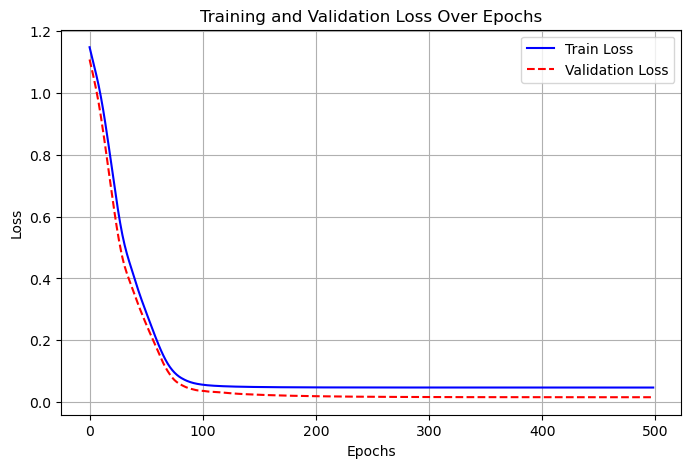

In [31]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color='blue')
plt.plot(val_losses, label="Validation Loss", color='red', linestyle='dashed')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

### validation loss가 더 낮은 이유

1. 훈련 데이터가 너무 적고 검증 데이터가 상대적으로 클 경우
2. Regularization가 강하게 작용하는 경우 (모델이 훈련 데이터에 지나치게 일반화되도록 강요받아 검증 데이터에서 오히려 더 좋은 성능을 보일 수 있음)
3. 보통 너무 적은 Epoch 학습 또는 너무 단순한 모델 구조 사용 (Underfitting)
4. 훈련 데이터가 이상값(Outliers)이 많은 경우
5. Batch Normalization과 Dropout을 동시에 사용할 때

### 검증 데이터는 무엇인가?

> 훈련 중 모델의 성능을 평가하고, 과적합 여부를 판단하기 위해 사용하는 데이터 <br>
> 검증 데이터를 사용하면 조기종료를 적용할 수 있다.
> 학습 데이터로 사용되진 않지만 학습에 기여하는 데이터 셋 

<img src='사진/train_val_test.png' width=400 height=300 alt="train_val_test"/>

### BatchNormalization(배치 정규화)

> 각 배치(batch)마다 입력을 정규화(Mean=0, Variance=1)하여 학습을 안정화하는 방법

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Iris 데이터 로드 및 전처리
iris = datasets.load_iris()
X, y = iris.data, iris.target

# 데이터 표준화 (각 특성의 평균을 0, 표준편차를 1로 조정)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 훈련 데이터와 검증 데이터 분리 (80% 훈련, 20% 검증)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
y_train, y_val = torch.tensor(y_train, dtype=torch.long), torch.tensor(y_val, dtype=torch.long)

# PyTorch Dataset & DataLoader 적용 (미니배치 학습)
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

batch_size = 16  # 미니배치 크기 설정
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# BatchNorm 적용한 nn.Sequential() DNN 모델 정의
model = nn.Sequential(
    nn.Linear(4, 10),
    nn.BatchNorm1d(10),  # BatchNorm1d -> 완전 연결 신경망, DNN)의 출력에 적용 / 1D 텐서(batch, features) 형태의 데이터에서 각 feature(특징)마다 정규화 수행
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.BatchNorm1d(5),  
    nn.ReLU(),
    nn.Linear(5, 3)  # 출력층 (클래스 개수 3개)
)

# 손실 함수 & 옵티마이저 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 조기 종료 설정
patience = 10  # 조기 종료 기준 (연속 10번 향상되지 않으면 중단)
best_val_loss = float('inf')  # 최소 검증 손실 초기값
counter = 0  # 성능이 향상되지 않은 epoch 횟수

# 모델 학습 (조기 종료 포함) + 손실값 저장
num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:  # 미니배치 학습 적용
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # 검증 데이터도 미니배치 적용
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            val_outputs = model(batch_X)
            val_loss += criterion(val_outputs, batch_y).item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss / len(train_loader):.4f}, Val Loss: {val_loss / len(val_loader):.4f}")

Epoch [1/100], Train Loss: 0.9954, Val Loss: 0.9752
Epoch [2/100], Train Loss: 0.7895, Val Loss: 0.7724
Epoch [3/100], Train Loss: 0.6506, Val Loss: 0.6006
Epoch [4/100], Train Loss: 0.5754, Val Loss: 0.4788
Epoch [5/100], Train Loss: 0.4213, Val Loss: 0.3986
Epoch [6/100], Train Loss: 0.3966, Val Loss: 0.3272
Epoch [7/100], Train Loss: 0.2911, Val Loss: 0.2362
Epoch [8/100], Train Loss: 0.2879, Val Loss: 0.1757
Epoch [9/100], Train Loss: 0.1691, Val Loss: 0.1355
Epoch [10/100], Train Loss: 0.2814, Val Loss: 0.1296
Epoch [11/100], Train Loss: 0.1525, Val Loss: 0.1366
Epoch [12/100], Train Loss: 0.2099, Val Loss: 0.1230
Epoch [13/100], Train Loss: 0.1903, Val Loss: 0.0841
Epoch [14/100], Train Loss: 0.1541, Val Loss: 0.0828
Epoch [15/100], Train Loss: 0.1302, Val Loss: 0.0845
Epoch [16/100], Train Loss: 0.2300, Val Loss: 0.0784
Epoch [17/100], Train Loss: 0.1442, Val Loss: 0.0857
Epoch [18/100], Train Loss: 0.0969, Val Loss: 0.0865
Epoch [19/100], Train Loss: 0.1764, Val Loss: 0.0933
Ep

### 데이터 전처리 단계에서 정규화 vs 훈련 중 실시간 정규화

구분|StandardScaler|Batch Normalization
---|----|---
적용 시점|훈련 시작 전|훈련 중 매 미니배치마다
적용 대상|입력 데이터|신경망의 각 층의 출력값 
업데이트 방식|한 번 계산 후 고정 |매 미니배치마다 업데이트 
학습 가능 여부| X | scale(γ) & shift(β) 학습 가능 
과적합 방지효과| X | Dropout과 유사한 효과 
목적 |입력 데이터를 균일한 분포로 정규화로 학습 초기 속도 증가 |내부 레이어의 활성화 값을 정규화하여 학습 속도 증가

※ scale: 데이터의 분포의 범위를 조정하는 학습 가능한 파라미터 <br>
  shift: 데이터를 평행 이동하는 학습 가능한 파라미터 (데이터의 중심 또는 평균을 이동시킴) <br>

#### 왜 scale과 shift를 학습할까? 
일반적인 정규화(평균=0, 분산=1)는 입력 데이터를 지나치게 제한할 수 있음 <br>
그래서 신경망이 학습을 통해 최적의 γ와 β 값을 찾도록 만듦

## <a id='six'>6. Kaggle 데이터 셋을 활용한 DNN 학습 실습</a><br> 